# Import Library

In [5]:
!pip install Sastrawi
!pip install gensim
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 766.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [6]:
import re
import string
from tqdm import tqdm
from io import StringIO

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Global Configuration
pd.options.mode.chained_assignment = None
seed = 0
np.random.seed(seed)

# Download NLTK resource
nltk.download('punkt_tab')
nltk.download('stopwords')

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Load Dataset

In [37]:
# Load dataset (scraped) from github repository
url = 'https://raw.githubusercontent.com/adicamp/dicoding-belajar-fundamental-deep-learning/refs/heads/main/Proyek%20Analisis%20Sentimen/data/signal_app_reviews.csv'
df = pd.read_csv(url)

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c79af456-01f8-4ec7-833f-2347355eeb66,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan lebih bagus tp fungsional makin buruk...,1,1,2.1.1,2026-05-10 05:36:25,"Hai Sahabat SIGNAL, Mohon maaf atas kendala te...",2026-05-11 01:44:15,2.1.1
1,7a902561-4262-48b3-b45d-3fcb37a8740e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ditunggu aturan terbaru yang mana bayar pajak ...,1,11,2.1.1,2026-04-17 23:58:25,NaN,NaN,2.1.1
2,c47125d0-3155-45d5-b0e7-b453ae9d74c8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pas di update mau ngecek pajak kendaraan sendi...,1,8,2.1.1,2026-04-22 08:07:57,"Hai, terima kasih banyak atas ulasannya :) Ter...",2022-02-07 06:55:02,2.1.1
3,026afa12-8427-4c1d-b90d-7047b89d8f80,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ciri khas aplikasi goverment, lelet, fullbug, ...",1,1,2.1.1,2026-05-11 04:36:17,NaN,NaN,2.1.1
4,a0f9a8fa-d1cf-4d7b-b6d3-28e793646a45,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi sampah, saat menambahkan data kendara...",1,3,2.1.1,2026-05-05 07:16:44,NaN,NaN,2.1.1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   userName              20000 non-null  object
 2   userImage             20000 non-null  object
 3   content               20000 non-null  object
 4   score                 20000 non-null  int64 
 5   thumbsUpCount         20000 non-null  int64 
 6   reviewCreatedVersion  17878 non-null  object
 7   at                    20000 non-null  object
 8   replyContent          6883 non-null   object
 9   repliedAt             6883 non-null   object
 10  appVersion            17878 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


# Feature Selection & Data Cleaning

In [9]:
# Feature selection
df_selected = df[['content', 'score', 'at']]

df_selected.head()

,content,score,at
0,Tampilan lebih bagus tp fungsional makin buruk...,1,2026-05-10 05:36:25
1,Ditunggu aturan terbaru yang mana bayar pajak ...,1,2026-04-17 23:58:25
2,pas di update mau ngecek pajak kendaraan sendi...,1,2026-04-22 08:07:57
3,"aplikasi sampah, saat menambahkan data kendara...",1,2026-05-05 07:16:44
4,"terima kasih atas kemudahan membayar pajak,San...",5,2026-05-02 03:41:15


In [10]:
# Drop null data
clean_df = df_selected.dropna()

# Drop duplicate data
clean_df = clean_df.drop_duplicates()

# Reset index
clean_df = clean_df.reset_index(drop=True)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  20000 non-null  object
 1   score    20000 non-null  int64 
 2   at       20000 non-null  object
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


# Preprocessing

In [11]:
# Load slangwords Indonesia from public Github
url_salsabila = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'
url_aliakbars = 'https://raw.githubusercontent.com/aliakbars/bilp/master/singkatan-lib.csv'

df_slang_salsabila = pd.read_csv(url_salsabila)
dict_slang_salsabila = dict(zip(df_slang_salsabila['slang'], df_slang_salsabila['formal']))

df_slang_aliakbars = pd.read_csv(url_aliakbars, header=None, names=['slang', 'formal'])
dict_slang_aliakbars = dict(zip(df_slang_aliakbars['slang'], df_slang_aliakbars['formal']))

# Slangwords for Signal App
dict_signal = {
    'apk': 'aplikasi',
    'app': 'aplikasi',
    'stnk': 'surat tanda nomor kendaraan',
    'pkb': 'pajak kendaraan bermotor',
    'plat': 'nomor polisi',
    'cs': 'customer service',
    'eror': 'error'
}

# Gathering all slangwords
slang_dict = dict_slang_salsabila | dict_slang_aliakbars | dict_signal

In [12]:
# Initialize Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Initialize Stopwords Set
listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(stopwords.words('english'))
custom_stopwords = ['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"]
listStopwords.update(custom_stopwords)
# Whitelist stopwords for reviews
whitelist_words = {'tidak', 'bukan', 'jangan', 'kurang', 'oke', 'bagus', 'top'}
listStopwords = listStopwords - whitelist_words

In [13]:
def cleaningText(text):
  """
  Cleans the text by removing mentions, hashtags, RTs, URLs, numbers, and punctuation.
  """
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)
  text = re.sub(r'#[A-Za-z0-9_]+', '', text)
  text = re.sub(r'RT[\s]', '', text)
  text = re.sub(r"http\S+", '', text)
  text = re.sub(r'[0-9]+', '', text)
  text = re.sub(r'[^\w\s]', '', text)

  text = text.replace('\n', ' ')
  text = text.strip()
  return text

def casefoldingText(text):
  """
  Converts the text to lowercase for uniformity.
  """
  return text.lower()

def tokenizingText(text):
  """
  Splits the text into individual tokens (words).
  """
  return word_tokenize(text)

def filteringText(tokens):
  """
  Removes stop words from the list of tokens based on predefined stopword sets.
  """
  return [token for token in tokens if token not in listStopwords]

def stemmingText(text):
  """
  Reduces words to their base or dictionary form (morphological root).
  """
  return stemmer.stem(text)

def toSentence(list_words):
  """
  Joins a list of words back into a single string sentence.
  """
  return ' '.join(list_words)

def fix_slangwords(text):
  """
  Normalizes slang or informal words to their formal version based on a dictionary.
  """
  words = text.split()
  fixed_words = [slang_dict.get(word, word) for word in words]
  return ' '.join(fixed_words)

In [14]:
def preprocess_pipeline(text):
  """
  Consolidates the NLP process into a single linear pipeline.
  """
  # 1. Basic text processing
  text = casefoldingText(text)
  text = cleaningText(text)
  text = fix_slangwords(text)

  # 2. Tokenization and filtering
  tokens = tokenizingText(text)
  tokens = filteringText(tokens)

  # 3. Re-joining and stemming
  sentence = toSentence(tokens)
  final_text = stemmingText(sentence)

  return final_text

# Enable progress bar for processing tracking
tqdm.pandas(desc="Text Preprocessing")

# Apply the pipeline to the content column
clean_df['content_preprocessed'] = clean_df['content'].progress_apply(preprocess_pipeline)

# Display results
display(clean_df[['content', 'content_preprocessed']].head())

Text Preprocessing: 100%|██████████| 20000/20000 [16:51<00:00, 19.77it/s]


,content,content_preprocessed
0,Tampilan lebih bagus tp fungsional makin buruk...,tampil bagus fungsional buruk suruh verifikasi...
1,Ditunggu aturan terbaru yang mana bayar pajak ...,tunggu atur baru bayar pajak ktp bukan milik r...
2,pas di update mau ngecek pajak kendaraan sendi...,pas update ecek pajak kendara ribet mesti isi ...
3,"aplikasi sampah, saat menambahkan data kendara...",aplikasi sampah data kendara masuk detail data...
4,"terima kasih atas kemudahan membayar pajak,San...",terima kasih mudah bayar pajaksangat cepat mud...


# Data Labeling

**Lexicon Based Data Labeling**

In [15]:
# Loads positive lexicon data from GitHub
url_pos = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
url_neg = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'

df_pos = pd.read_csv(url_pos, header=None, names=['word', 'weight'])
df_neg = pd.read_csv(url_neg, header=None, names=['word', 'weight'])

# Convert to dictionary
lexicon_positive = dict(zip(df_pos['word'], df_pos['weight']))
lexicon_negative = dict(zip(df_neg['word'], df_neg['weight']))

In [16]:
def calculate_sentiment_score(text):
  """
  Calculates a sentiment score for a given text based on positive and negative lexicons.
  """
  words = str(text).split()
  score = 0

  for word in words:
    # Add weight if word is found in positive lexicon
    if word in lexicon_positive:
      score += lexicon_positive[word]

    # Subtract weight if word is found in negative lexicon
    if word in lexicon_negative:
      score -= abs(lexicon_negative[word])

  return score

def categorize_label(score):
  """
  Categorizes a numeric score into a sentiment label: positive, negative, or neutral.
  """
  if score > 0:
    return 'positive'
  elif score < 0:
    return 'negative'
  else:
    return 'neutral'

In [17]:
# Calculate sentiment score and label
clean_df['sentiment_score'] = clean_df['content_preprocessed'].apply(calculate_sentiment_score)
clean_df['sentiment_label_lexicon'] = clean_df['sentiment_score'].apply(categorize_label)

# Display the sentiment analysis results
print(clean_df['sentiment_label_lexicon'].value_counts())

sentiment_label_lexicon
negative    13748
positive     5445
neutral       807
Name: count, dtype: int64


**Score Based (rating) Data Labeling**

In [18]:
def map_score_to_label(score):
  """
  Converts a numeric rating (1-5) into a categorical sentiment label.
  - Ratings 4 & 5 -> positive
  - Ratings 1 & 2 -> negative
  - Rating 3      -> neutral
  """
  if score > 3:
    return 'positive'
  elif score < 3:
    return 'negative'
  else:
    return 'neutral'

# Apply mapping to create a score-based sentiment label
clean_df['sentiment_label_score'] = clean_df['score'].apply(map_score_to_label)

# Display the frequency of each sentiment label
print(clean_df['sentiment_label_score'].value_counts())

sentiment_label_score
positive    12795
negative     5978
neutral      1227
Name: count, dtype: int64


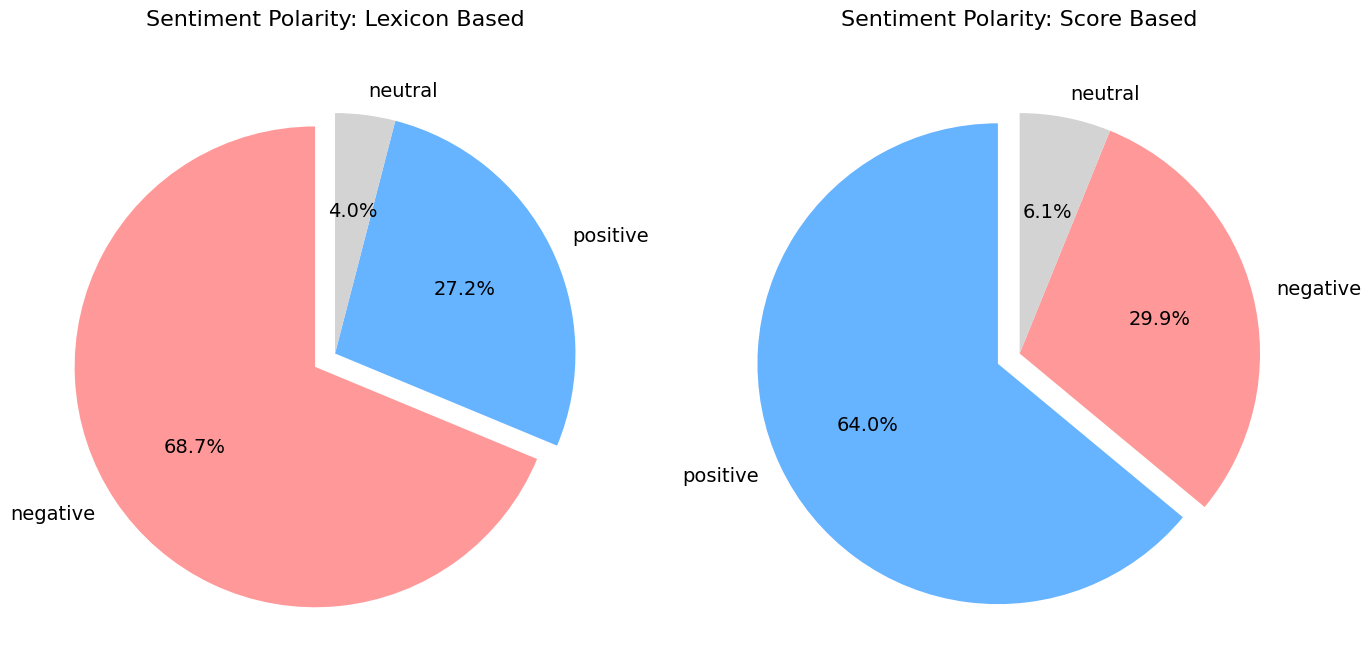

In [19]:
# Prepare data for both labeling methods
labels_lex = clean_df['sentiment_label_lexicon'].value_counts()
labels_score = clean_df['sentiment_label_score'].value_counts()

# Define a consistent color palette
color_map = {
    'positive': '#66b3ff',
    'negative': '#ff9999',
    'neutral': '#d3d3d3'
}

# Map colors based on the index order of the results
colors_lex = [color_map[label] for label in labels_lex.index]
colors_score = [color_map[label] for label in labels_score.index]

# Initialize a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
explode = (0.1, 0, 0)

# Plot 1: Lexicon Based Sentiment
ax[0].pie(
    x=labels_lex.values,
    labels=labels_lex.index,
    autopct='%1.1f%%',
    explode=explode,
    colors=colors_lex,
    textprops={'fontsize': 14},
    startangle=90
)
ax[0].set_title('Sentiment Polarity: Lexicon Based', fontsize=16, pad=20)

# Plot 2: Score Based Sentiment
ax[1].pie(
    x=labels_score.values,
    labels=labels_score.index,
    autopct='%1.1f%%',
    explode=explode,
    colors=colors_score,
    textprops={'fontsize': 14},
    startangle=90
)
ax[1].set_title('Sentiment Polarity: Score Based', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

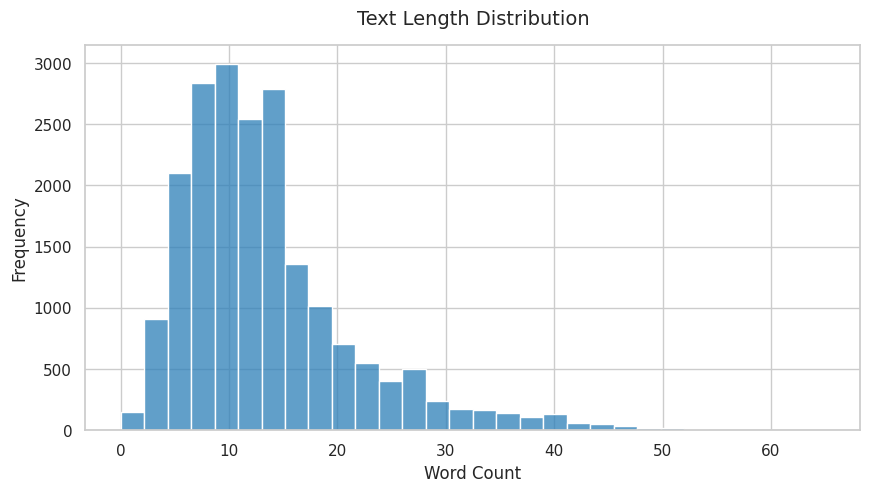

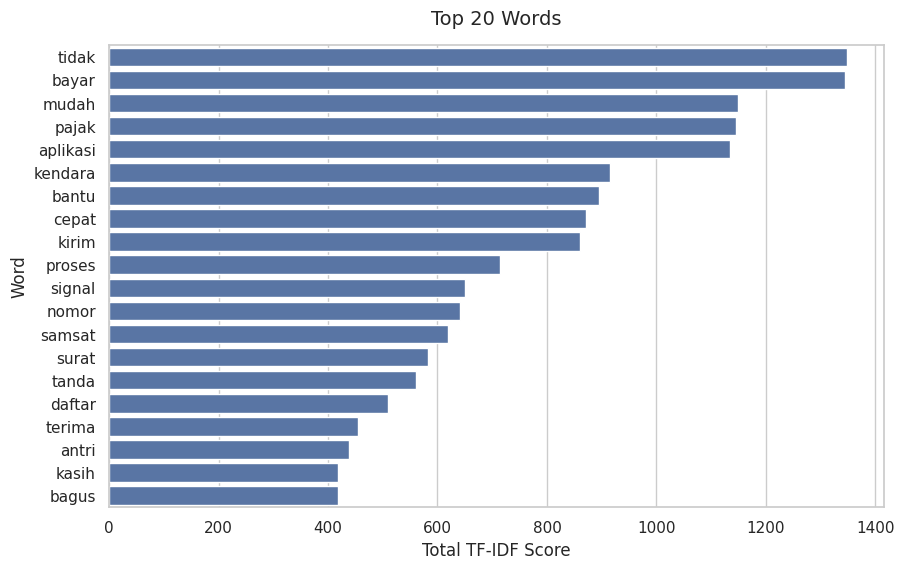

In [20]:
# Set seaborn theme for modern aesthetics
sns.set_theme(style="whitegrid")

# Visualization of Text Length Distribution
plt.figure(figsize=(10, 5))

# Calculate text length based on word count
clean_df['text_length'] = clean_df['content_preprocessed'].apply(lambda x: len(str(x).split()))

sns.histplot(data=clean_df, x='text_length', bins=30, color='#2c7fb8')
plt.title('Text Length Distribution', fontsize=14, pad=15)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

# Visualization of Top Words (TF-IDF)
plt.figure(figsize=(10, 6))

# Initialize and fit TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(clean_df['content_preprocessed'].astype(str))

# Calculate aggregate TF-IDF scores from sparse matrix
word_scores = np.array(X.sum(axis=0)).flatten()
word_names = vectorizer.get_feature_names_out()

# Create a DataFrame for top 20 words
tfidf_df = pd.DataFrame({'word': word_names, 'score': word_scores})
tfidf_df = tfidf_df.sort_values('score', ascending=False).head(20)

sns.barplot(x='score', y='word', data=tfidf_df)
plt.title('Top 20 Words', fontsize=14, pad=15)
plt.xlabel('Total TF-IDF Score')
plt.ylabel('Word')
plt.show()

# Modeling

In [21]:
X = clean_df['content_preprocessed']
y = clean_df['sentiment_label_score']

**Ket:** Score Based Labeling dipilih karena distribusi 20 kata teratas terbukti didominasi positif. Metode ini menjamin objektivitas ground truth.

In [22]:
def evaluate_model(y_true, y_pred, schema_name, classes):
  """
  Prints comprehensive evaluation metrics to monitor model performance.

  Parameters:
  - y_true: Ground truth target values.
  - y_pred: Predicted values from the model.
  - schema_name: Name of the experiment schema and dataset type.
  - classes: List of class labels for classification.
  """
  print(f"\n{'='*55}")
  print(f"  EVALUATION: {schema_name.upper()}")
  print(f"{'='*55}")

  # Calculate and print overall accuracy
  acc = accuracy_score(y_true, y_pred)
  print(f"Overall Accuracy: {acc * 100:.2f}%\n")

  # Print detailed classification report
  print("Classification Report:")
  print(classification_report(y_true, y_pred, target_names=classes))

# Schema 1

**Experiment Spesification:**
* **Labeling:** Score-Based (rating)
* **Feature Extraction:** TF-IDF Unigram
* **Algorithm:** Logistic Regression
* **Splitting Data:** 80% Train, 20% Test

In [35]:
# Feature Extraction (TF-IDF Unigram)
tfidf_uni = TfidfVectorizer(min_df=5, max_df=0.8, ngram_range=(1, 1))
X_s1 = tfidf_uni.fit_transform(X)
y_s1 = y

# Train-Test Split (80:20)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=42, stratify=y_s1
)

# Model Training
print("Training Logistic Regression model...")
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_s1, y_train_s1)

# Prediction
y_pred_train_s1 = model_lr.predict(X_train_s1)
y_pred_test_s1 = model_lr.predict(X_test_s1)

# Evaluation
evaluate_model(y_train_s1, y_pred_train_s1, "Schema 1 Train", model_lr.classes_)
evaluate_model(y_test_s1, y_pred_test_s1, "Schema 1 Test", model_lr.classes_)

Training Logistic Regression model...

  EVALUATION: SCHEMA 1 TRAIN
Overall Accuracy: 87.87%

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.90      0.85      4782
     neutral       0.75      0.04      0.07       982
    positive       0.92      0.95      0.93     10236

    accuracy                           0.88     16000
   macro avg       0.82      0.63      0.62     16000
weighted avg       0.87      0.88      0.85     16000


  EVALUATION: SCHEMA 1 TEST
Overall Accuracy: 86.55%

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.86      0.83      1196
     neutral       0.30      0.01      0.02       245
    positive       0.90      0.95      0.92      2559

    accuracy                           0.87      4000
   macro avg       0.67      0.61      0.59      4000
weighted avg       0.83      0.87      0.84      4000



# Schema 2

**Experiment Spesification:**
* **Labeling:** Score-Based (rating)
* **Feature Extraction:** TF-IDF Unigram + Bigram
* **Algorithm:** SVM
* **Splitting Data:** 70% Train, 30% Test

In [30]:
# Feature Extraction (TF-IDF Unigram + Bigram)
tfidf_s2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_s2 = tfidf_s2.fit_transform(clean_df['content_preprocessed'])
y_s2 = y

# Train-Test Split (70:30)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
  X_s2, y_s2, test_size=0.3, random_state=42, stratify=y_s2
)

# Model Training (SVM)
print("Training SVM model...")
model_svm = SVC(kernel='linear', class_weight='balanced', random_state=42)
model_svm.fit(X_train_s2, y_train_s2)

# Prediction
y_pred_train_s2 = model_svm.predict(X_train_s2)
y_pred_test_s2 = model_svm.predict(X_test_s2)

# Evaluation
evaluate_model(y_train_s2, y_pred_train_s2, "Schema 2 Train", model_svm.classes_)
evaluate_model(y_test_s2, y_pred_test_s2, "Schema 2 Test", model_svm.classes_)

Training SVM model...

  EVALUATION: SCHEMA 2 TRAIN
Overall Accuracy: 89.45%

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      4185
     neutral       0.48      0.96      0.64       859
    positive       0.99      0.90      0.94      8956

    accuracy                           0.89     14000
   macro avg       0.78      0.91      0.82     14000
weighted avg       0.93      0.89      0.90     14000


  EVALUATION: SCHEMA 2 TEST
Overall Accuracy: 81.32%

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.78      0.78      1793
     neutral       0.18      0.34      0.24       368
    positive       0.95      0.87      0.91      3839

    accuracy                           0.81      6000
   macro avg       0.64      0.67      0.64      6000
weighted avg       0.86      0.81      0.83      6000



# Schema 3

**Experiment Spesification:**
* **Labeling:** Score-Based (rating)
* **Feature Extraction:** Word2Vec
* **Algorithm:** Bidirectional Long Short-Term Memory (Bi-LSTM)
* **Splitting Data:** 80% Train, 20% Test

In [36]:
# Label Encoding
encoder = LabelEncoder()
y_w2v = encoder.fit_transform(y)

# Local Word2Vec Training
print("Training Word2Vec representation model...")
sentences = [str(text).split() for text in clean_df['content_preprocessed']]
w2v_model = Word2Vec(sentences, vector_size=128, window=5, min_count=3, workers=4, epochs=10)

# Tokenization & Padding
vocab_size = 5000
max_length = 50
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(clean_df['content_preprocessed'])
X_seq = tokenizer.texts_to_sequences(clean_df['content_preprocessed'])
X_pad = pad_sequences(X_seq, maxlen=max_length, padding='post', truncating='post')

# Building Embedding Matrix
embedding_matrix = np.zeros((vocab_size, 128))
for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# Data Splitting (80:20)
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_pad, y_w2v, test_size=0.2, random_state=42, stratify=y_w2v
)

# Bi-LSTM Model Architecture
model_bilstm = Sequential([
    Embedding(vocab_size, 128, weights=[embedding_matrix], input_length=max_length, trainable=True),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model_bilstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

# Model Training
print("\nTraining Bi-LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_w2v = model_bilstm.fit(
    X_train_w2v, y_train_w2v,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_w2v, y_test_w2v),
    callbacks=[early_stop],
    verbose=1
)

# Prediction
y_pred_prob_train = model_bilstm.predict(X_train_w2v)
y_pred_prob_test = model_bilstm.predict(X_test_w2v)

# Take highest class
y_pred_train_w2v = np.argmax(y_pred_prob_train, axis=1)
y_pred_test_w2v = np.argmax(y_pred_prob_test, axis=1)

# Inverse Transform
y_train_true_labels = encoder.inverse_transform(y_train_w2v)
y_pred_train_labels = encoder.inverse_transform(y_pred_train_w2v)

y_test_true_labels = encoder.inverse_transform(y_test_w2v)
y_pred_test_labels = encoder.inverse_transform(y_pred_test_w2v)

# Evaluation
evaluate_model(
    y_true=y_train_true_labels,
    y_pred=y_pred_train_labels,
    schema_name="Schema 3 Train",
    classes=encoder.classes_
)

evaluate_model(
    y_true=y_test_true_labels,
    y_pred=y_pred_test_labels,
    schema_name="Schema 3 Test",
    classes=encoder.classes_
)

Training Word2Vec representation model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,000 (2.44 MB)

 Trainable params: 640,000 (2.44 MB)

 Non-trainable params: 0 (0.00 B)


Training Bi-LSTM...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8444 - loss: 0.4345 - val_accuracy: 0.8680 - val_loss: 0.3664
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.8662 - loss: 0.3721 - val_accuracy: 0.8735 - val_loss: 0.3586
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8762 - loss: 0.3494 - val_accuracy: 0.8742 - val_loss: 0.3515
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8843 - loss: 0.3189 - val_accuracy: 0.8758 - val_loss: 0.3511
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8921 - loss: 0.2981 - val_accuracy: 0.8710 - val_loss: 0.3693
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8986 - loss: 0.2726 - val_accuracy: 0.8708 - val_loss: 0.3767
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9057 - loss: 0.2557 - val_accuracy: 0.8660 - val_loss: 0.3849
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4

**KESIMPULAN SINGKAT MODEL:**

Akurasi tertinggi diraih oleh Bi-LSTM + Word2Vec (87.48%), lalu disusul Logistic Regression (86.55%), dan terakhir SVM (81.32%). Meski akurasi global tinggi, seluruh model gagal mendeteksi kelas neutral (F1-score rendah) akibat ketidakseimbangan data (class imbalance) yang memicu bias pada kelas mayoritas.

In [26]:
def predict_schema_1(text):
    # Preprocessing
    cleaned = preprocess_pipeline(text)
    # Vectorization
    vec = tfidf_uni.transform([cleaned])
    # Prediction
    return model_lr.predict(vec)[0]

def predict_schema_2(text):
    # Preprocessing
    cleaned = preprocess_pipeline(text)
    # Vectorization
    vec = tfidf_s2.transform([cleaned])
    # Prediction
    return model_svm.predict(vec)[0]

def predict_schema_3(text):
    # Preprocessing
    cleaned = preprocess_pipeline(text)
    # Tokenization
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=50, padding='post', truncating='post')
    # Prediction
    pred = model_bilstm.predict(pad, verbose=0)
    idx = np.argmax(pred, axis=1)
    return encoder.inverse_transform(idx)[0]

# Inference Testing on All Schemas
test_reviews = [
    "Aplikasi ini sangat membantu, bayar pajak jadi lebih cepat dan mudah",
    "Kenapa aplikasinya sering error saat mau login? Tolong diperbaiki",
    "Biasa saja lumayan"
]

print(f"{'Review':<60} | {'S1 (LR)':<10} | {'S2 (SVM)':<10} | {'S3 (LSTM)':<10}")
print("-" * 105)

for review in test_reviews:
    res1 = predict_schema_1(review)
    res2 = predict_schema_2(review)
    res3 = predict_schema_3(review)
    print(f"{review[:58]:<60} | {res1:<10} | {res2:<10} | {res3:<10}")

Review                                                       | S1 (LR)    | S2 (SVM)   | S3 (LSTM) 
---------------------------------------------------------------------------------------------------------
Aplikasi ini sangat membantu, bayar pajak jadi lebih cepat   | positive   | positive   | positive  
Kenapa aplikasinya sering error saat mau login? Tolong dip   | negative   | neutral    | negative  
Biasa saja lumayan                                           | positive   | positive   | positive  


**ANALISIS INFERENSI:**
1. **Logistic Regression**: berhasil mendeteksi keluhan teknis sebagai negative, namun tetap gagal pada kalimat ambigu.
2. **SVM + Balanced**: Kurang akurat dalam memisahkan kelas minoritas; gagal mendeteksi keluhan sebagai negative dan justru menggesernya ke neutral, menunjukkan kerancuan pada batas keputusan.
3. **Bi-LSTM + Word2Vec**: Memberikan performa tertinggi dan paling kontekstual, meskipun tetap lemah pada kelas minoritas.